# Numerisk integrasjon

```{admonition} Læringsutbytte
Etter å ha arbeidet med dette temaet, skal du kunne:

1. forklare hvordan et bestemt integral kan tilnærmes som en sum av små arealer
2. implementere venstre-, høyre- og midtpunktstilnærming
3. forklare og implementere trapesmetoden
4. sammenlikne numeriske metoder ved hjelp av feil og konvergens
5. integrere funksjoner og eksperimentelle data med SciPy
6. tolke integraler i en kjemisk sammenheng
```

## Integrasjon i kjemi

Et bestemt integral summerer bidrag over et intervall. Det gjør integrasjon relevant i mange kjemiske situasjoner:

- arealet under en kromatografisk topp
- arealet under et NMR-signal
- total varme fra en varmefluks som varierer med tid
- integrasjon av fartslover og andre differensiallikninger

Numerisk integrasjon er spesielt nyttig når vi bare har **diskrete måledata** og ingen funksjon vi kan antiderivere.


## Rektangelmetoden

Det bestemte integralet

$$\int_a^b f(x)\,dx$$

kan tilnærmes ved å dele intervallet i $n$ små intervaller med bredde

$$h=\frac{b-a}{n}.$$

For hvert intervall bruker vi et rektangel. Høyden kan bestemmes fra venstre endepunkt, høyre endepunkt eller midtpunktet.

Venstretilnærming:

$$\int_a^b f(x)\,dx\approx h\sum_{k=0}^{n-1}f(a+kh).$$

Høyretilnærming:

$$\int_a^b f(x)\,dx\approx h\sum_{k=1}^{n}f(a+kh).$$

Midtpunktstilnærming:

$$\int_a^b f(x)\,dx\approx h\sum_{k=0}^{n-1}f\left(a+\left(k+\frac12\right)h\right).$$


In [1]:
def rektangel_venstre(f, a, b, n):
    h = (b - a) / n
    areal = 0.0
    x = a
    for k in range(n):
        areal = areal + f(x) * h
        x = x + h
    return areal


def rektangel_hoyre(f, a, b, n):
    h = (b - a) / n
    areal = 0.0
    x = a + h
    for k in range(n):
        areal = areal + f(x) * h
        x = x + h
    return areal


def rektangel_midt(f, a, b, n):
    h = (b - a) / n
    areal = 0.0
    x = a + h/2
    for k in range(n):
        areal = areal + f(x) * h
        x = x + h
    return areal


Vi tester metodene på

$$f(x)=x^3$$

i intervallet $[0,5]$. Her kjenner vi den analytiske verdien og kan bruke den som kontroll:

$$\int_0^5x^3\,dx=\left[\frac{x^4}{4}\right]_0^5=156.25.$$

Når vi sammenlikner et numerisk og et analytisk resultat, må vi passe på at begge beregningene bruker de samme integrasjonsgrensene.


In [2]:
def f(x):
    return x**3

a = 0
b = 5
n = 100
eksakt = (b**4 - a**4) / 4

print("Venstre:", rektangel_venstre(f, a, b, n))
print("Høyre:", rektangel_hoyre(f, a, b, n))
print("Midtpunkt:", rektangel_midt(f, a, b, n))
print("Eksakt:", eksakt)


Venstre: 153.14062499999935
Høyre: 159.39062499999932
Midtpunkt: 156.24218749999937
Eksakt: 156.25


### Prøv selv

Fullfør rektangelmetodene og undersøk hvordan resultatet endres når du øker antall rektangler.

<iframe src="../../basthon/?from=examples/numerisk_integrasjon_rektangler.py" width="100%" height="620" frameborder="0" title="Prøv selv: numerisk integrasjon" loading="lazy" allowfullscreen></iframe>

## Konvergens

Et numerisk svar bør ikke vurderes ut fra ett enkelt valg av $n$. Vi kan øke antall intervaller og undersøke om resultatet **stabiliserer seg**.


In [3]:
n_verdier = [10, 20, 50, 100, 200, 500, 1000]

print(" n      venstre-feil     midtpunkt-feil")
for n in n_verdier:
    feil_v = abs(rektangel_venstre(f, a, b, n) - eksakt)
    feil_m = abs(rektangel_midt(f, a, b, n) - eksakt)
    print(f"{n:4d}    {feil_v:12.6f}    {feil_m:14.6f}")


 n      venstre-feil     midtpunkt-feil
  10       29.687500          0.781250
  20       15.234375          0.195312
  50        6.187500          0.031250
 100        3.109375          0.007813
 200        1.558594          0.001953
 500        0.624375          0.000313
1000        0.312344          0.000078


## Trapesmetoden

I stedet for et flatt rektangeltak trekker trapesmetoden en rett linje mellom funksjonsverdiene i endepunktene.

For ett intervall $[x_i,x_{i+1}]$ er arealet

$$A_i\approx\frac{f(x_i)+f(x_{i+1})}{2}h.$$

Med $n$ like brede intervaller blir

$$\int_a^b f(x)\,dx\approx h\left[\frac{f(a)+f(b)}{2}+\sum_{i=1}^{n-1}f(a+ih)\right].$$


In [4]:
def trapesmetoden(f, a, b, n):
    h = (b - a) / n
    areal = 0.0
    x = a
    for k in range(n):
        areal = areal + (f(x) + f(x + h)) / 2 * h
        x = x + h
    return areal


print("Trapes:", trapesmetoden(f, 0, 5, 100))
print("Eksakt:", 156.25)


Trapes: 156.2656249999993
Eksakt: 156.25


## Simpsons metode

Simpsons metode bruker andregradspolynomer over par av intervaller. Metoden krever et **partall** antall delintervaller og er ofte svært presis for glatte funksjoner.

$$\int_a^b f(x)\,dx\approx\frac{h}{3}\left[f(a)+f(b)+4\sum_{\text{odde }k}f(x_k)+2\sum_{\text{partall }k}f(x_k)\right].$$


In [5]:
def simpsons_metode(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("n må være et partall.")

    h = (b - a) / n
    areal = 0.0
    x = a
    for k in range(n + 1):
        if k == 0 or k == n:
            areal = areal + f(x)
        elif k % 2 == 0:
            areal = areal + 2*f(x)
        else:
            areal = areal + 4*f(x)
        x = x + h
    return areal * h / 3


print("Simpson:", simpsons_metode(f, 0, 5, 100))


Simpson: 156.24999999999935


## Bruk av biblioteker

Når vi har forstått prinsippet, kan vi bruke ferdige funksjoner. I moderne SciPy heter de relevante funksjonene blant annet:

- `integrate.trapezoid(y, x)` for diskrete data
- `integrate.simpson(y, x=x)` for diskrete data
- `integrate.quad(f, a, b)` for en funksjon

`trapezoid` og `simpson` er de moderne navnene; eldre kode kan inneholde de utgåtte navnene `trapz` og `simps`.


In [6]:
from scipy import integrate
import numpy as np

x = np.linspace(0, 5, 1001)
y = f(x)

trapes = integrate.trapezoid(y, x)
simpson = integrate.simpson(y, x=x)
quad_verdi, quad_feil = integrate.quad(f, 0, 5)

print("trapezoid:", trapes)
print("simpson:", simpson)
print("quad:", quad_verdi)
print("estimert absolutt feil fra quad:", quad_feil)


trapezoid: 156.25015624999997
simpson: 156.25
quad: 156.25000000000003
estimert absolutt feil fra quad: 1.7347234759768075e-12


## Kjemisk eksempel: areal under et kromatogram

Et kromatogram består av signal som funksjon av retensjonstid. Arealet under en topp kan være proporsjonalt med stoffmengden eller konsentrasjonen etter en passende kalibrering.

Her lager vi et enkelt kunstig kromatogram med to topper og integrerer signalet numerisk. Poenget er at vi nå integrerer **målepunkter**, ikke en symbolsk funksjon.


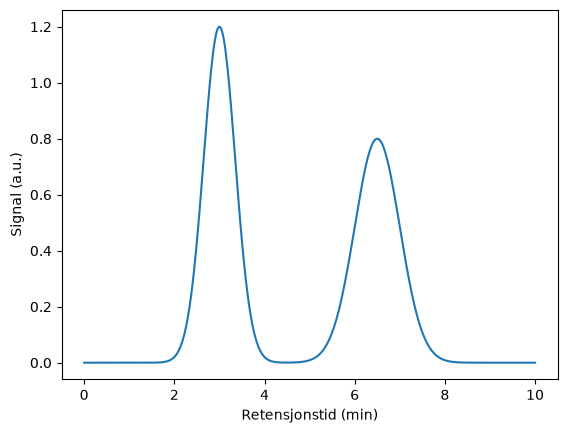

In [7]:
import matplotlib.pyplot as plt

tid = np.linspace(0, 10, 501)

topp_1 = 1.2*np.exp(-0.5*((tid - 3.0)/0.35)**2)
topp_2 = 0.8*np.exp(-0.5*((tid - 6.5)/0.50)**2)
signal = topp_1 + topp_2

plt.plot(tid, signal)
plt.xlabel("Retensjonstid (min)")
plt.ylabel("Signal (a.u.)")
plt.show()


In [8]:
maske_1 = (tid >= 2.0) & (tid <= 4.2)
maske_2 = (tid >= 5.0) & (tid <= 8.0)

areal_1 = integrate.trapezoid(signal[maske_1], tid[maske_1])
areal_2 = integrate.trapezoid(signal[maske_2], tid[maske_2])

print(f"Areal topp 1: {areal_1:.3f} a.u.·min")
print(f"Areal topp 2: {areal_2:.3f} a.u.·min")
print(f"Arealforhold topp 1 / topp 2: {areal_1/areal_2:.3f}")


Areal topp 1: 1.050 a.u.·min
Areal topp 2: 1.000 a.u.·min
Arealforhold topp 1 / topp 2: 1.050


```{admonition} Tolkning av enheter
:class: note
Et integral får enheten til $y$ multiplisert med enheten til $x$. Hvis signalet er i mAU og tiden i minutter, blir topparealet i mAU·min. En kalibreringsmodell kan deretter knytte arealet til konsentrasjon eller stoffmengde.
```

## Videre utforskning: multippel integrasjon

I enkelte deler av kjemien, særlig kvantekjemi og statistisk termodynamikk, møter vi integraler over flere variabler. SciPy har også funksjoner som `dblquad` og `tplquad`. Dette er nyttig å kjenne til, men er ikke et hovedmål i dette kapitlet.


In [9]:
def g(y, x):
    return x*np.sin(y) - y*np.exp(x)

dobbel, feil = integrate.dblquad(g, -1, 1, 0, np.pi/2)
print("Dobbeltintegral:", dobbel)


Dobbeltintegral: -2.899692718238082


## Kort oppsummering

- Numerisk integrasjon summerer små bidrag over et intervall.
- Rektangel-, trapes- og Simpson-metodene bruker ulike tilnærminger mellom punktene.
- Et numerisk resultat bør kontrolleres ved å endre steglengde eller antall intervaller.
- For eksperimentelle data er `trapezoid` og `simpson` særlig nyttige.
- Integralets enhet og kjemiske betydning må alltid tolkes sammen med dataene.


## Oppgaver

```{admonition} Oppgave 1 – rektangelmetoder
:class: tip
Integrer $f(x)=x^2-2x+4$ fra 2 til 8 med venstre-, høyre- og midtpunktstilnærming. Bruk først $n=10$ og deretter $n=100$. Sammenlikn med den analytiske verdien.
```

```{admonition} Oppgave 2 – konvergens
:class: tip
Lag et plott av absolutt feil som funksjon av $n$ for venstretilnærmingen, midtpunktstilnærmingen og trapesmetoden. Bruk logaritmiske akser.
```

```{admonition} Oppgave 3 – kromatografisk topp
:class: tip
Lag en Gauss-formet topp med sentrum ved 5,0 min og legg til svak tilfeldig støy. Integrer toppen med trapesmetoden. Hvordan endres arealet hvis du flytter integrasjonsgrensene?
```

```{admonition} Oppgave 4 – NMR
:class: tip
To NMR-signaler har numeriske arealer 3,02 og 1,01. Hva kan arealforholdet tyde på om relative antall hydrogenatomer dersom responsen kan sammenliknes direkte?
```

```{admonition} Oppgave 5 – varme fra effektdata
:class: tip
Et kalorimeter registrerer varmeeffekt $P(t)$ i watt hvert sekund. Forklar hvorfor integralet $\int P(t)\,dt$ gir energi, og skriv kode som integrerer et kunstig datasett. Hvilken enhet får svaret?
```

```{admonition} Oppgave 6 – metodevalg
:class: tip
Når vil du bruke `quad`, og når vil du bruke `trapezoid`? Gi ett kjemisk eksempel på hver.
```

```{admonition} Oppgave 7 – Simpson
:class: tip
Implementer Simpsons metode selv. Sammenlikn med `scipy.integrate.simpson` for $f(x)=\cos x + 2$ på intervallet $[2,12]$.
```

```{admonition} Oppgave 8 – vanskelig funksjon
:class: tip
Studer $f(x)=\sin(1/x)$ nær $x=0$. Plott funksjonen og undersøk hvordan forskjellige integrasjonsgrenser og oppløsninger påvirker resultatet. Forklar hvorfor dette er et numerisk krevende problem.
```


## Videoer

````{tab-set}
```{tab-item} Integrasjon
<iframe width="850" height="450" src="https://www.youtube.com/embed/XHahL9ER2wA" title="Integrasjon" frameborder="0" allowfullscreen></iframe>
```
```{tab-item} Ulike metoder
<iframe width="850" height="450" src="https://www.youtube.com/embed/KOL92Jxp_Yk" title="Numeriske integrasjonsmetoder" frameborder="0" allowfullscreen></iframe>
```
````
